# Credit Risk Monitoring Framework

## Project Overview

This notebook implements a structured credit risk monitoring framework applicable to a multi-entity portfolio comprising both financial institutions and sovereign counterparties. The analysis is modelled on the workflows employed by a credit risk desk within an investment bank or asset management firm.

### Entities Covered

**Banks (15 entities):** JPMorgan Chase, HSBC, BNP Paribas, Deutsche Bank, UniCredit, Santander, ING Group, Societe Generale, Barclays, UBS, Nordea, Intesa Sanpaolo, ABN AMRO, Commerzbank, Monte dei Paschi.

**Sovereigns (10 entities):** Germany, France, United States, United Kingdom, Japan, Italy, Spain, Greece, Turkey, Brazil.

### Objective

The objective of this project is to: (1) construct internal credit scores for each entity using a multi-factor scoring model calibrated to publicly observable financial and macroeconomic indicators; (2) monitor real-time market signals including CDS spreads, bond yields, equity returns and implied volatility; (3) generate watchlists and analyst-ready credit notes; and (4) produce exportable outputs suitable for use in risk reporting and credit committee presentations.

### Notebook Structure

1. Setup: imports, directory paths, plotting configuration
2. Synthetic market data generation (90 business days, 25 entities)
3. Data loading and validation
4. Data cleaning and type enforcement
5. Feature engineering for banks and sovereigns
6. Internal scoring models (banks and sovereigns)
7. Market monitoring and alert generation
8. Final rating mapping and unified rating table
9. Watchlist generation
10. Output export (CSV files and credit note markdown)
11. Visualizations
12. Key conclusions

## 1. Setup: Imports and Paths

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import textwrap
import warnings
warnings.filterwarnings("ignore")

BASE_DIR = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").exists())
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False
})
sns.set_palette("tab10")
print("Environment ready.")

Environment ready.


## 2. Generate Synthetic Market Data

This section constructs a synthetic time series dataset spanning 90 business days ending 31 December 2025, covering all 25 monitored entities. The simulation is designed to reflect plausible market dynamics:

- **CDS spreads and bond spreads** follow mean-reverting random walks, where daily shocks are drawn from a normal distribution scaled to a fraction of the prevailing level, and a drift term pulls the series back toward its base level. For higher-risk entities (Monte dei Paschi, Turkey, Greece, Brazil), a small probability of discrete stress shocks is included to replicate idiosyncratic credit events.
- **Bond yields** follow a simple random walk with daily increments drawn from a normal distribution, reflecting interest rate sensitivity.
- **Equity returns** are generated using a lognormal model calibrated to entity-specific annualised volatilities. Distressed entities carry a small probability of large negative daily returns.
- **Implied equity volatility** is computed as a 30-day rolling standard deviation of daily returns, annualised.
- **Currency returns** are included primarily for sovereign entities and reflect FX risk, with a persistent depreciation bias applied to Turkey.
- **Market flag (news)** is a binary indicator representing the occurrence of a material news event, drawn with 5% daily probability (10% for high-risk entities).

The resulting dataset is saved to `data/market_data_sample.csv`.

In [8]:
np.random.seed(42)

dates = pd.bdate_range(end=pd.Timestamp("2025-12-31"), periods=90)

# Base levels for each entity
base_cds = {
    "JPMorgan Chase": 45, "HSBC": 62, "BNP Paribas": 68, "Deutsche Bank": 115,
    "UniCredit": 122, "Santander": 92, "ING Group": 56, "Societe Generale": 108,
    "Barclays": 77, "UBS": 72, "Nordea": 38, "Intesa Sanpaolo": 118,
    "ABN AMRO": 66, "Commerzbank": 102, "Monte dei Paschi": 285,
    "Germany": 12, "France": 35, "United States": 22, "United Kingdom": 28,
    "Japan": 30, "Italy": 148, "Spain": 82, "Greece": 215, "Turkey": 390, "Brazil": 265
}

base_spread = {
    "JPMorgan Chase": 38, "HSBC": 55, "BNP Paribas": 60, "Deutsche Bank": 105,
    "UniCredit": 110, "Santander": 82, "ING Group": 48, "Societe Generale": 98,
    "Barclays": 68, "UBS": 62, "Nordea": 32, "Intesa Sanpaolo": 108,
    "ABN AMRO": 58, "Commerzbank": 92, "Monte dei Paschi": 265,
    "Germany": 5, "France": 28, "United States": 18, "United Kingdom": 22,
    "Japan": 25, "Italy": 130, "Spain": 70, "Greece": 190, "Turkey": 360, "Brazil": 240
}

base_yield = {
    "JPMorgan Chase": 4.8, "HSBC": 4.6, "BNP Paribas": 4.5, "Deutsche Bank": 4.9,
    "UniCredit": 5.0, "Santander": 4.7, "ING Group": 4.5, "Societe Generale": 4.8,
    "Barclays": 4.7, "UBS": 3.8, "Nordea": 3.9, "Intesa Sanpaolo": 4.9,
    "ABN AMRO": 4.4, "Commerzbank": 4.8, "Monte dei Paschi": 7.2,
    "Germany": 2.5, "France": 3.1, "United States": 4.3, "United Kingdom": 4.2,
    "Japan": 1.1, "Italy": 3.8, "Spain": 3.3, "Greece": 3.6, "Turkey": 28.0, "Brazil": 13.5
}

base_vol = {
    "JPMorgan Chase": 20, "HSBC": 22, "BNP Paribas": 24, "Deutsche Bank": 30,
    "UniCredit": 28, "Santander": 26, "ING Group": 22, "Societe Generale": 28,
    "Barclays": 24, "UBS": 22, "Nordea": 18, "Intesa Sanpaolo": 27,
    "ABN AMRO": 22, "Commerzbank": 30, "Monte dei Paschi": 48,
    "Germany": 16, "France": 17, "United States": 18, "United Kingdom": 18,
    "Japan": 17, "Italy": 20, "Spain": 19, "Greece": 28, "Turkey": 45, "Brazil": 35
}

banks_list = [
    "JPMorgan Chase", "HSBC", "BNP Paribas", "Deutsche Bank", "UniCredit",
    "Santander", "ING Group", "Societe Generale", "Barclays", "UBS",
    "Nordea", "Intesa Sanpaolo", "ABN AMRO", "Commerzbank", "Monte dei Paschi"
]
sovereigns_list = [
    "Germany", "France", "United States", "United Kingdom", "Japan",
    "Italy", "Spain", "Greece", "Turkey", "Brazil"
]
stress_entities = {"Monte dei Paschi", "Turkey", "Greece", "Brazil"}

all_entities = banks_list + sovereigns_list

rows = []

for entity in all_entities:
    entity_type = "Bank" if entity in banks_list else "Sovereign"
    is_stress = entity in stress_entities

    cds_val = float(base_cds[entity])
    spread_val = float(base_spread[entity])
    yield_val = float(base_yield[entity])
    bvol = base_vol[entity]
    daily_sigma = bvol / 100.0 / np.sqrt(252)

    # Track equity price for 5-day return calculation
    price = 100.0
    price_history = []
    daily_returns = []

    for i, dt in enumerate(dates):
        # --- CDS mean-reverting walk ---
        cds_drift = -0.05 * (cds_val - base_cds[entity])
        cds_shock = np.random.normal(0, max(3, cds_val * 0.025))
        if is_stress and np.random.rand() < 0.04:
            cds_shock += np.random.uniform(15, 45)
        cds_val = max(1.0, cds_val + cds_drift + cds_shock)

        # --- Bond spread mean-reverting walk ---
        spread_drift = -0.05 * (spread_val - base_spread[entity])
        spread_shock = np.random.normal(0, max(2, spread_val * 0.025))
        if is_stress and np.random.rand() < 0.04:
            spread_shock += np.random.uniform(15, 45)
        spread_val = max(1.0, spread_val + spread_drift + spread_shock)

        # --- Bond yield random walk ---
        yield_val = max(0.01, yield_val + np.random.normal(0, 0.04))

        # --- Equity daily return ---
        eq_ret_1d = np.random.normal(0.0003, daily_sigma)
        if entity in {"Monte dei Paschi", "Turkey"} and np.random.rand() < 0.05:
            eq_ret_1d -= np.random.uniform(0.02, 0.06)
        price = price * (1 + eq_ret_1d)
        price_history.append(price)
        daily_returns.append(eq_ret_1d)

        # 5-day equity return
        if i >= 5:
            eq_ret_5d = (price_history[i] / price_history[i - 5]) - 1
        else:
            eq_ret_5d = np.nan

        # 30-day rolling vol (annualised)
        if i >= 29:
            eq_vol_30d = np.std(daily_returns[i - 29: i + 1]) * np.sqrt(252) * 100
        else:
            eq_vol_30d = float(bvol)  # fill early values with base vol

        # --- Currency return ---
        fx_mean = -0.001 if entity == "Turkey" else 0.0
        currency_ret_1m = np.random.normal(fx_mean, 0.01)

        # --- News flag ---
        news_prob = 0.10 if is_stress else 0.05
        market_flag_news = int(np.random.rand() < news_prob)

        rows.append({
            "date": dt,
            "entity_name": entity,
            "entity_type": entity_type,
            "cds_5y_bps": round(cds_val, 2),
            "bond_spread_bps": round(spread_val, 2),
            "bond_yield_10y": round(yield_val, 4),
            "equity_return_1d": round(eq_ret_1d, 6),
            "equity_return_5d": round(eq_ret_5d, 6) if not np.isnan(eq_ret_5d) else np.nan,
            "equity_vol_30d": round(eq_vol_30d, 4),
            "currency_return_1m": round(currency_ret_1m, 6),
            "market_flag_news": market_flag_news
        })

market_df = pd.DataFrame(rows)
market_df.to_csv(DATA_DIR / "market_data_sample.csv", index=False)
print(f"market_data_sample.csv saved. Shape: {market_df.shape}")
print(f"Distinct entities: {market_df['entity_name'].nunique()}")
print(f"Date range: {market_df['date'].min()} to {market_df['date'].max()}")

market_data_sample.csv saved. Shape: (2250, 11)
Distinct entities: 25
Date range: 2025-08-28 00:00:00 to 2025-12-31 00:00:00


## 3. Load and Validate Data

The three source datasets are loaded from the `data/` directory. Basic validation checks are performed to confirm shape, column types, null counts, and entity coverage.

In [9]:
banks_df = pd.read_csv(DATA_DIR / "banks_sample.csv")
sovereigns_df = pd.read_csv(DATA_DIR / "sovereigns_sample.csv")
market_df = pd.read_csv(DATA_DIR / "market_data_sample.csv")

print("=== Banks ===")
print(f"Shape: {banks_df.shape}")
print(banks_df.dtypes)
print(f"Nulls:\n{banks_df.isnull().sum()}")
print()
print("=== Sovereigns ===")
print(f"Shape: {sovereigns_df.shape}")
print(sovereigns_df.dtypes)
print(f"Nulls:\n{sovereigns_df.isnull().sum()}")
print()
print("=== Market Data ===")
print(f"Shape: {market_df.shape}")
print(market_df.dtypes)
print(f"Nulls:\n{market_df.isnull().sum()}")

=== Banks ===
Shape: (15, 9)
name                object
cet1_ratio         float64
npl_ratio          float64
roe                float64
leverage_ratio     float64
loan_to_deposit    float64
cost_to_income     float64
liquidity_ratio    float64
ext_rating          object
dtype: object
Nulls:
name               0
cet1_ratio         0
npl_ratio          0
roe                0
leverage_ratio     0
loan_to_deposit    0
cost_to_income     0
liquidity_ratio    0
ext_rating         0
dtype: int64

=== Sovereigns ===
Shape: (10, 9)
name                   object
debt_gdp              float64
fiscal_balance        float64
inflation             float64
fx_reserves_months    float64
gdp_growth            float64
political_risk        float64
current_account       float64
ext_rating             object
dtype: object
Nulls:
name                  0
debt_gdp              0
fiscal_balance        0
inflation             0
fx_reserves_months    0
gdp_growth            0
political_risk        0
current_acc

In [10]:
# Verify all 25 entities are present in market data
expected_entities = set(banks_list + sovereigns_list)
actual_entities = set(market_df["entity_name"].unique())
missing = expected_entities - actual_entities
print(f"Expected entities: {len(expected_entities)}")
print(f"Found in market data: {len(actual_entities)}")
print(f"Missing: {missing if missing else 'None'}")

# Verify date range
market_df["date"] = pd.to_datetime(market_df["date"])
print(f"Date range: {market_df['date'].min().date()} to {market_df['date'].max().date()}")
print(f"Unique dates: {market_df['date'].nunique()}")

print()
print("=== Quick describe - Market Data ===")
market_df[["cds_5y_bps", "bond_spread_bps", "bond_yield_10y", "equity_vol_30d"]].describe().round(2)

Expected entities: 25
Found in market data: 25
Missing: None
Date range: 2025-08-28 to 2025-12-31
Unique dates: 90

=== Quick describe - Market Data ===


,cds_5y_bps,bond_spread_bps,bond_yield_10y,equity_vol_30d
count,2250.00,2250.00,2250.00,2250.00
mean,110.45,98.18,5.52,24.89
std,99.90,91.27,5.04,9.61
min,1.00,1.00,0.78,11.89
25%,43.84,37.57,3.68,18.18
50%,77.46,68.82,4.51,22.00
75%,123.22,108.23,4.92,28.00
max,497.99,454.05,28.07,66.79


## 4. Data Cleaning

This section enforces correct data types on all columns and converts date fields to `datetime` objects. Numeric columns in the banks and sovereigns datasets are cast to `float64` to prevent any implicit type errors during scoring. As all data is either loaded from pre-validated CSVs or generated synthetically, no erroneous values are expected; however, a clipping step is applied as a defensive measure.

In [11]:
# --- Banks: datetime and numeric conversion ---
banks_df["last_update"] = pd.to_datetime(banks_df["last_update"])

bank_numeric_cols = [
    "total_assets", "total_equity", "net_income", "roe", "cet1_ratio",
    "npl_ratio", "loan_deposit_ratio", "cost_income_ratio", "liquidity_ratio"
]
for col in bank_numeric_cols:
    banks_df[col] = pd.to_numeric(banks_df[col], errors="coerce")

# Defensive clip: CET1 ratio between 0 and 50, NPL between 0 and 100
banks_df["cet1_ratio"] = banks_df["cet1_ratio"].clip(0, 50)
banks_df["npl_ratio"] = banks_df["npl_ratio"].clip(0, 100)
banks_df["liquidity_ratio"] = banks_df["liquidity_ratio"].clip(50, 500)

# --- Sovereigns: datetime and numeric conversion ---
sovereigns_df["last_update"] = pd.to_datetime(sovereigns_df["last_update"])

sov_numeric_cols = [
    "gdp_growth", "inflation", "fiscal_balance_gdp", "debt_gdp",
    "current_account_gdp", "fx_reserves_months_import", "political_risk_score"
]
for col in sov_numeric_cols:
    sovereigns_df[col] = pd.to_numeric(sovereigns_df[col], errors="coerce")

# --- Market data: datetime ---
market_df["date"] = pd.to_datetime(market_df["date"])

market_numeric_cols = [
    "cds_5y_bps", "bond_spread_bps", "bond_yield_10y",
    "equity_return_1d", "equity_return_5d", "equity_vol_30d", "currency_return_1m"
]
for col in market_numeric_cols:
    market_df[col] = pd.to_numeric(market_df[col], errors="coerce")

print("Data cleaning complete.")
print(f"Banks nulls after cleaning: {banks_df[bank_numeric_cols].isnull().sum().sum()}")
print(f"Sovereigns nulls after cleaning: {sovereigns_df[sov_numeric_cols].isnull().sum().sum()}")
print(f"Market data nulls (equity_return_5d expected for first 5 rows per entity): "
      f"{market_df['equity_return_5d'].isnull().sum()}")

print("\n--- Banks cleaned summary ---")
banks_df[bank_numeric_cols].describe().round(3)

KeyError: 'last_update'

## 5. Feature Engineering - Banks

Derived features are constructed from the raw balance sheet and income statement ratios for each bank. These features serve both as inputs to the internal scoring model and as qualitative descriptors for analyst-facing outputs. The categorisation bins are calibrated to standard regulatory and industry benchmarks (e.g., Basel III CET1 thresholds, EBA NPL guidance).

In [ ]:
# Leverage ratio: equity as a share of total assets
banks_df["leverage_ratio"] = banks_df["total_equity"] / banks_df["total_assets"]

# Earnings buffer: net income as share of total assets (proxy for asset profitability)
banks_df["earnings_buffer"] = banks_df["net_income"] / banks_df["total_assets"]

# Categorical features based on standard benchmarks
banks_df["capital_strength"] = pd.cut(
    banks_df["cet1_ratio"],
    bins=[0, 10, 13, 15, 20, 100],
    labels=["Weak", "Below Avg", "Average", "Strong", "Very Strong"]
)

banks_df["asset_quality"] = pd.cut(
    banks_df["npl_ratio"],
    bins=[0, 1, 3, 5, 10, 100],
    labels=["Excellent", "Good", "Moderate", "Weak", "Distressed"]
)

banks_df["funding_risk"] = pd.cut(
    banks_df["loan_deposit_ratio"],
    bins=[0, 0.7, 0.85, 0.95, 1.05, 10],
    labels=["Very Low", "Low", "Moderate", "High", "Very High"]
)

banks_df["efficiency"] = pd.cut(
    banks_df["cost_income_ratio"],
    bins=[0, 45, 55, 65, 75, 200],
    labels=["Excellent", "Good", "Moderate", "Weak", "Poor"]
)

display_cols = [
    "entity_name", "leverage_ratio", "earnings_buffer",
    "capital_strength", "asset_quality", "funding_risk", "efficiency"
]
print("Banks feature table:")
banks_df[display_cols].to_string(index=False)

Banks feature table:


'     entity_name  leverage_ratio  earnings_buffer capital_strength asset_quality funding_risk efficiency\n  JPMorgan Chase        0.075491         0.012823          Average     Excellent     Very Low       Good\n            HSBC        0.055198         0.004064          Average          Good          Low   Moderate\n     BNP Paribas        0.043300         0.003807          Average          Good          Low       Weak\n   Deutsche Bank        0.043381         0.003665          Average      Moderate          Low       Weak\n       UniCredit        0.061090         0.006673           Strong      Moderate     Moderate       Good\n       Santander        0.058680         0.006846        Below Avg      Moderate     Moderate       Good\n       ING Group        0.055388         0.006747          Average          Good          Low   Moderate\nSociete Generale        0.041912         0.002685          Average      Moderate     Moderate       Weak\n        Barclays        0.047619         0.00

In [ ]:
print(banks_df[display_cols].to_string(index=False))

     entity_name  leverage_ratio  earnings_buffer capital_strength asset_quality funding_risk efficiency
  JPMorgan Chase        0.075491         0.012823          Average     Excellent     Very Low       Good
            HSBC        0.055198         0.004064          Average          Good          Low   Moderate
     BNP Paribas        0.043300         0.003807          Average          Good          Low       Weak
   Deutsche Bank        0.043381         0.003665          Average      Moderate          Low       Weak
       UniCredit        0.061090         0.006673           Strong      Moderate     Moderate       Good
       Santander        0.058680         0.006846        Below Avg      Moderate     Moderate       Good
       ING Group        0.055388         0.006747          Average          Good          Low   Moderate
Societe Generale        0.041912         0.002685          Average      Moderate     Moderate       Weak
        Barclays        0.047619         0.004762      

## 6. Feature Engineering - Sovereigns

Sovereign feature engineering translates macroeconomic indicators into qualitative risk labels. The categorisation reflects standard sovereign credit analysis frameworks as used by major rating agencies and supranational institutions. Each dimension captures a distinct risk pillar: fiscal sustainability, debt burden, external sector resilience, macroeconomic performance, and political risk.

In [ ]:
# Fiscal strength: categorised by fiscal balance as % of GDP
def categorise_fiscal(fb):
    if fb > 0:
        return "Surplus"
    elif fb >= -3:
        return "Balanced"
    elif fb >= -5:
        return "Moderate Deficit"
    else:
        return "High Deficit"

sovereigns_df["fiscal_strength"] = sovereigns_df["fiscal_balance_gdp"].apply(categorise_fiscal)

# Debt burden: categorised by debt/GDP ratio
sovereigns_df["debt_burden"] = pd.cut(
    sovereigns_df["debt_gdp"],
    bins=[0, 60, 90, 120, 10000],
    labels=["Low", "Moderate", "High", "Very High"]
)

# External strength: combination of current account and FX reserves
def categorise_external(row):
    ca = row["current_account_gdp"]
    fx = row["fx_reserves_months_import"]
    if ca > 2 and fx > 5:
        return "Strong"
    elif ca > 0 and fx > 3:
        return "Adequate"
    elif ca > -3 and fx > 2:
        return "Moderate"
    else:
        return "Weak"

sovereigns_df["external_strength"] = sovereigns_df.apply(categorise_external, axis=1)

# Macro stability: combination of inflation and GDP growth
def categorise_macro(row):
    infl = row["inflation"]
    gdp = row["gdp_growth"]
    if infl < 3 and gdp > 2:
        return "Strong"
    elif infl < 5 and gdp > 0.5:
        return "Stable"
    elif infl < 10 and gdp >= 0:
        return "Mixed"
    else:
        return "Unstable"

sovereigns_df["macro_stability"] = sovereigns_df.apply(categorise_macro, axis=1)

# Political overlay: categorised by political risk score (1=low, 10=high risk)
def categorise_political(score):
    if score <= 2:
        return "Low Risk"
    elif score <= 4:
        return "Moderate"
    elif score <= 7:
        return "Elevated"
    else:
        return "High Risk"

sovereigns_df["political_overlay"] = sovereigns_df["political_risk_score"].apply(categorise_political)

sov_display_cols = [
    "entity_name", "fiscal_strength", "debt_burden",
    "external_strength", "macro_stability", "political_overlay"
]
print("Sovereigns feature table:")
print(sovereigns_df[sov_display_cols].to_string(index=False))

Sovereigns feature table:
   entity_name  fiscal_strength debt_burden external_strength macro_stability political_overlay
       Germany         Balanced    Moderate          Adequate           Mixed          Low Risk
        France     High Deficit        High          Moderate          Stable          Low Risk
 United States     High Deficit   Very High              Weak          Stable          Moderate
United Kingdom Moderate Deficit        High              Weak          Stable          Low Risk
         Japan Moderate Deficit   Very High            Strong          Stable          Low Risk
         Italy Moderate Deficit   Very High          Moderate          Stable          Moderate
         Spain Moderate Deficit        High          Moderate          Strong          Moderate
        Greece          Surplus   Very High              Weak          Stable          Moderate
        Turkey     High Deficit         Low              Weak        Unstable          Elevated
        Brazil

## 7. Internal Scoring Model - Banks

The internal bank scoring model produces a composite score on a 0-100 scale, aggregating seven financial risk dimensions through a weighted average. The weights reflect the relative importance of each metric in assessing overall creditworthiness:

| Component | Metric | Weight |
|---|---|---|
| Capital Adequacy | CET1 Ratio | 25% |
| Asset Quality | NPL Ratio | 20% |
| Profitability | ROE | 15% |
| Leverage | Leverage Ratio | 10% |
| Funding | Loan/Deposit Ratio | 10% |
| Efficiency | Cost/Income Ratio | 10% |
| Liquidity | Liquidity Ratio | 10% |

Each component is linearly scaled between plausible minimum and maximum values, producing a normalised sub-score between 0 and 100. Key risk drivers are identified as the two components whose weighted contribution to the total score is lowest, indicating where the entity's credit profile is most constrained.

In [ ]:
BANK_WEIGHTS = {
    "CET1 Ratio": 0.25,
    "NPL Ratio": 0.20,
    "ROE": 0.15,
    "Leverage Ratio": 0.10,
    "Loan/Deposit Ratio": 0.10,
    "Cost/Income Ratio": 0.10,
    "Liquidity Ratio": 0.10
}

def score_bank_components(row):
    """Compute 0-100 component scores and weighted total for a single bank row."""
    s_cet1 = float(np.clip((row["cet1_ratio"] - 8) / (20 - 8) * 100, 0, 100))
    s_npl  = float(np.clip((10 - row["npl_ratio"]) / 10 * 100, 0, 100))
    s_roe  = float(np.clip((row["roe"] - (-5)) / (20 - (-5)) * 100, 0, 100))
    s_lev  = float(np.clip((row["leverage_ratio"] - 0.02) / (0.10 - 0.02) * 100, 0, 100))
    s_ldr  = float(np.clip(100 - abs(row["loan_deposit_ratio"] * 100 - 80) * 1.5, 0, 100))
    s_cir  = float(np.clip((85 - row["cost_income_ratio"]) / (85 - 40) * 100, 0, 100))
    s_liq  = float(np.clip((row["liquidity_ratio"] - 100) / (200 - 100) * 100, 0, 100))

    component_scores = {
        "CET1 Ratio": s_cet1,
        "NPL Ratio": s_npl,
        "ROE": s_roe,
        "Leverage Ratio": s_lev,
        "Loan/Deposit Ratio": s_ldr,
        "Cost/Income Ratio": s_cir,
        "Liquidity Ratio": s_liq
    }

    total_score = sum(
        component_scores[k] * BANK_WEIGHTS[k] for k in component_scores
    )

    # Weighted contribution of each component
    weighted_contribs = {k: component_scores[k] * BANK_WEIGHTS[k] for k in component_scores}
    sorted_drivers = sorted(weighted_contribs, key=weighted_contribs.get)

    return {
        "bank_internal_score": round(total_score, 2),
        "key_risk_driver_1": sorted_drivers[0],
        "key_risk_driver_2": sorted_drivers[1],
        "top_strength_1": sorted_drivers[-1],
        "top_strength_2": sorted_drivers[-2],
        "comp_CET1 Ratio": round(s_cet1, 2),
        "comp_NPL Ratio": round(s_npl, 2),
        "comp_ROE": round(s_roe, 2),
        "comp_Leverage Ratio": round(s_lev, 2),
        "comp_Loan/Deposit Ratio": round(s_ldr, 2),
        "comp_Cost/Income Ratio": round(s_cir, 2),
        "comp_Liquidity Ratio": round(s_liq, 2)
    }

bank_scores = banks_df.apply(score_bank_components, axis=1, result_type="expand")
banks_df = pd.concat([banks_df, bank_scores], axis=1)

print("Banks internal scoring complete.")
print(banks_df[["entity_name", "bank_internal_score", "key_risk_driver_1", "key_risk_driver_2"]].to_string(index=False))

Banks internal scoring complete.
     entity_name  bank_internal_score key_risk_driver_1 key_risk_driver_2
  JPMorgan Chase                70.99   Liquidity Ratio Cost/Income Ratio
            HSBC                58.99   Liquidity Ratio    Leverage Ratio
     BNP Paribas                54.30   Liquidity Ratio    Leverage Ratio
   Deutsche Bank                51.31 Cost/Income Ratio    Leverage Ratio
       UniCredit                63.16   Liquidity Ratio    Leverage Ratio
       Santander                59.64   Liquidity Ratio    Leverage Ratio
       ING Group                65.31    Leverage Ratio   Liquidity Ratio
Societe Generale                47.99   Liquidity Ratio    Leverage Ratio
        Barclays                58.52    Leverage Ratio   Liquidity Ratio
             UBS                64.29 Cost/Income Ratio    Leverage Ratio
          Nordea                76.19    Leverage Ratio   Liquidity Ratio
 Intesa Sanpaolo                68.12   Liquidity Ratio    Leverage Ratio
     

## 8. Internal Scoring Model - Sovereigns

The sovereign scoring model mirrors the bank model in structure but is calibrated to macroeconomic and political risk dimensions relevant to government counterparties. The weights reflect standard sovereign credit methodology:

| Component | Metric | Weight |
|---|---|---|
| Debt Sustainability | Debt/GDP | 25% |
| Fiscal Position | Fiscal Balance/GDP | 20% |
| Price Stability | Inflation | 15% |
| Growth Momentum | GDP Growth | 10% |
| External Buffers | FX Reserves | 15% |
| External Balance | Current Account/GDP | 5% |
| Governance | Political Risk Score | 10% |

In [ ]:
SOV_WEIGHTS = {
    "Debt/GDP": 0.25,
    "Fiscal Balance/GDP": 0.20,
    "Inflation": 0.15,
    "GDP Growth": 0.10,
    "FX Reserves": 0.15,
    "Current Account/GDP": 0.05,
    "Political Risk Score": 0.10
}

def score_sovereign_components(row):
    """Compute 0-100 component scores and weighted total for a single sovereign row."""
    s_debt   = float(np.clip((150 - row["debt_gdp"]) / (150 - 30) * 100, 0, 100))
    s_fiscal = float(np.clip((row["fiscal_balance_gdp"] + 10) / (5 + 10) * 100, 0, 100))
    s_infl   = float(np.clip((50 - row["inflation"]) / (50 - 1) * 100, 0, 100))
    s_gdp    = float(np.clip((row["gdp_growth"] + 2) / (6 + 2) * 100, 0, 100))
    s_fx     = float(np.clip((row["fx_reserves_months_import"] - 1) / (12 - 1) * 100, 0, 100))
    s_ca     = float(np.clip((row["current_account_gdp"] + 10) / (10 + 10) * 100, 0, 100))
    s_pol    = float(np.clip((10 - row["political_risk_score"]) / 10 * 100, 0, 100))

    component_scores = {
        "Debt/GDP": s_debt,
        "Fiscal Balance/GDP": s_fiscal,
        "Inflation": s_infl,
        "GDP Growth": s_gdp,
        "FX Reserves": s_fx,
        "Current Account/GDP": s_ca,
        "Political Risk Score": s_pol
    }

    total_score = sum(
        component_scores[k] * SOV_WEIGHTS[k] for k in component_scores
    )

    weighted_contribs = {k: component_scores[k] * SOV_WEIGHTS[k] for k in component_scores}
    sorted_drivers = sorted(weighted_contribs, key=weighted_contribs.get)

    return {
        "sovereign_internal_score": round(total_score, 2),
        "key_risk_driver_1": sorted_drivers[0],
        "key_risk_driver_2": sorted_drivers[1],
        "top_strength_1": sorted_drivers[-1],
        "top_strength_2": sorted_drivers[-2],
        "comp_Debt/GDP": round(s_debt, 2),
        "comp_Fiscal Balance/GDP": round(s_fiscal, 2),
        "comp_Inflation": round(s_infl, 2),
        "comp_GDP Growth": round(s_gdp, 2),
        "comp_FX Reserves": round(s_fx, 2),
        "comp_Current Account/GDP": round(s_ca, 2),
        "comp_Political Risk Score": round(s_pol, 2)
    }

sov_scores = sovereigns_df.apply(score_sovereign_components, axis=1, result_type="expand")
sovereigns_df = pd.concat([sovereigns_df, sov_scores], axis=1)

print("Sovereigns internal scoring complete.")
print(sovereigns_df[["entity_name", "sovereign_internal_score", "key_risk_driver_1", "key_risk_driver_2"]].to_string(index=False))

Sovereigns internal scoring complete.
   entity_name  sovereign_internal_score   key_risk_driver_1   key_risk_driver_2
       Germany                     61.27          GDP Growth         FX Reserves
        France                     45.38 Current Account/GDP         FX Reserves
 United States                     40.12         FX Reserves Current Account/GDP
United Kingdom                     46.11         FX Reserves Current Account/GDP
         Japan                     54.08            Debt/GDP Current Account/GDP
         Italy                     40.59         FX Reserves            Debt/GDP
         Spain                     50.17         FX Reserves Current Account/GDP
        Greece                     42.38            Debt/GDP Current Account/GDP
        Turkey                     46.92           Inflation Current Account/GDP
        Brazil                     56.51 Current Account/GDP  Fiscal Balance/GDP


## 9. Market Monitoring Alerts

Market-based alerts are computed from the time series data to flag entities exhibiting material deterioration over a 5-business-day window. Four alert types are defined, each calibrated to detect statistically and practically significant adverse moves:

- **CDS Alert**: 5-day widening in CDS 5Y spread exceeding 20 bps, indicating rising credit risk perception.
- **Spread Alert**: 5-day widening in bond spread exceeding 25 bps.
- **Equity Alert**: 5-day cumulative equity return below -10%, indicating significant equity stress.
- **Volatility Alert**: 30-day realised equity volatility exceeding 35% annualised, indicating elevated uncertainty.

In [ ]:
market_df = market_df.sort_values(["entity_name", "date"]).reset_index(drop=True)

# 5-day lagged CDS and spread per entity
market_df["cds_5d_change"] = (
    market_df["cds_5y_bps"]
    - market_df.groupby("entity_name")["cds_5y_bps"].shift(5)
)
market_df["spread_5d_change"] = (
    market_df["bond_spread_bps"]
    - market_df.groupby("entity_name")["bond_spread_bps"].shift(5)
)

# Alert flags
market_df["CDS_ALERT"]    = (market_df["cds_5d_change"] > 20).fillna(False)
market_df["SPREAD_ALERT"] = (market_df["spread_5d_change"] > 25).fillna(False)
market_df["EQUITY_ALERT"] = (market_df["equity_return_5d"] < -0.10).fillna(False)
market_df["VOL_ALERT"]    = (market_df["equity_vol_30d"] > 35).fillna(False)

alert_cols = ["CDS_ALERT", "SPREAD_ALERT", "EQUITY_ALERT", "VOL_ALERT"]
market_df["alert_count"] = market_df[alert_cols].sum(axis=1)

print("Alert frequency across all 90-day observations:")
for col in alert_cols:
    print(f"  {col}: {market_df[col].sum()} alerts ({market_df[col].mean()*100:.1f}% of rows)")

print()
max_date = market_df["date"].max()
latest_alerts = market_df[market_df["date"] == max_date].copy()
print(f"Latest date: {max_date.date()}")
print("Entities with highest alert counts on latest date:")
print(
    latest_alerts[["entity_name", "alert_count"] + alert_cols]
    .sort_values("alert_count", ascending=False)
    .head(10)
    .to_string(index=False)
)

Alert frequency across all 90-day observations:
  CDS_ALERT: 64 alerts (2.8% of rows)
  SPREAD_ALERT: 35 alerts (1.6% of rows)
  EQUITY_ALERT: 28 alerts (1.2% of rows)
  VOL_ALERT: 228 alerts (10.1% of rows)

Latest date: 2025-12-31
Entities with highest alert counts on latest date:
     entity_name  alert_count  CDS_ALERT  SPREAD_ALERT  EQUITY_ALERT  VOL_ALERT
     Commerzbank            1      False         False         False       True
          Turkey            1      False         False         False       True
          Greece            1      False          True         False      False
Monte dei Paschi            1      False         False         False       True
        ABN AMRO            0      False         False         False      False
           Japan            0      False         False         False      False
  United Kingdom            0      False         False         False      False
       UniCredit            0      False         False         False      Fa

## 10. Final Rating Mapping

Internal scores are mapped to a letter rating scale analogous to conventional agency ratings. This allows direct comparison with external ratings and facilitates communication with internal credit committees. The mapping thresholds are calibrated so that investment-grade begins at BBB (score >= 65).

In [ ]:
def map_to_rating(score):
    """Map a numeric internal score (0-100) to a letter rating category."""
    if score >= 85:
        return "AA"
    elif score >= 75:
        return "A"
    elif score >= 65:
        return "BBB"
    elif score >= 55:
        return "BB"
    elif score >= 40:
        return "B"
    else:
        return "CCC"

banks_df["implied_internal_rating"] = banks_df["bank_internal_score"].apply(map_to_rating)
sovereigns_df["implied_internal_rating"] = sovereigns_df["sovereign_internal_score"].apply(map_to_rating)

print("=== Banks: Internal vs External Rating ===")
print(banks_df[["entity_name", "bank_internal_score", "implied_internal_rating", "rating_external"]].to_string(index=False))

print()
print("=== Sovereigns: Internal vs External Rating ===")
print(sovereigns_df[["entity_name", "sovereign_internal_score", "implied_internal_rating", "rating_external"]].to_string(index=False))

=== Banks: Internal vs External Rating ===
     entity_name  bank_internal_score implied_internal_rating rating_external
  JPMorgan Chase                70.99                     BBB              A+
            HSBC                58.99                      BB               A
     BNP Paribas                54.30                       B              A+
   Deutsche Bank                51.31                       B            BBB+
       UniCredit                63.16                      BB             BBB
       Santander                59.64                      BB              A-
       ING Group                65.31                     BBB              A+
Societe Generale                47.99                       B              A-
        Barclays                58.52                      BB               A
             UBS                64.29                      BB              A+
          Nordea                76.19                       A             AA-
 Intesa Sanpaolo     

## 11. Combine and Build Unified Rating Table

A consolidated rating table is constructed by merging bank and sovereign data. To simulate a temporal comparison, a previous snapshot score is generated using a controlled random perturbation, allowing computation of score changes and deterioration flags.

In [ ]:
np.random.seed(99)

# Build bank section of rating table - include strength columns for credit notes
bank_table = banks_df[[
    "entity_name", "bank_internal_score", "implied_internal_rating",
    "rating_external", "key_risk_driver_1", "key_risk_driver_2",
    "top_strength_1", "top_strength_2"
]].copy()
bank_table.rename(columns={"bank_internal_score": "internal_score"}, inplace=True)
bank_table["entity_type"] = "Bank"

# Simulate previous snapshot with random noise
bank_table["prev_score"] = np.clip(
    bank_table["internal_score"] + np.random.normal(0, 7, len(bank_table)),
    0, 100
)

# Build sovereign section
sov_table = sovereigns_df[[
    "entity_name", "sovereign_internal_score", "implied_internal_rating",
    "rating_external", "key_risk_driver_1", "key_risk_driver_2",
    "top_strength_1", "top_strength_2"
]].copy()
sov_table.rename(columns={"sovereign_internal_score": "internal_score"}, inplace=True)
sov_table["entity_type"] = "Sovereign"
sov_table["prev_score"] = np.clip(
    sov_table["internal_score"] + np.random.normal(0, 7, len(sov_table)),
    0, 100
)

# Combine and compute change metrics
rating_table = pd.concat([bank_table, sov_table], ignore_index=True)
rating_table["score_change"] = rating_table["internal_score"] - rating_table["prev_score"]
rating_table["deterioration_flag"] = rating_table["score_change"] < -10

# Compute market alert count per entity on latest date
alert_summary = (
    latest_alerts.groupby("entity_name")[alert_cols]
    .sum()
    .sum(axis=1)
    .reset_index()
    .rename(columns={0: "market_alert_count"})
)

rating_table = rating_table.merge(alert_summary, on="entity_name", how="left")
rating_table["market_alert_count"] = rating_table["market_alert_count"].fillna(0).astype(int)

print("Unified rating table:")
print(rating_table[[
    "entity_name", "entity_type", "internal_score", "implied_internal_rating",
    "rating_external", "score_change", "deterioration_flag", "market_alert_count"
]].to_string(index=False))

Unified rating table:
     entity_name entity_type  internal_score implied_internal_rating rating_external  score_change  deterioration_flag  market_alert_count
  JPMorgan Chase        Bank           70.99                     BBB              A+      0.996512               False                   0
            HSBC        Bank           58.99                      BB               A    -14.400552                True                   0
     BNP Paribas        Bank           54.30                       B              A+     -1.982834               False                   0
   Deutsche Bank        Bank           51.31                       B            BBB+     -9.308684               False                   0
       UniCredit        Bank           63.16                      BB             BBB      1.082353               False                   0
       Santander        Bank           59.64                      BB              A-      0.483216               False                   0
     

## 12. Watchlist Generation

The watchlist captures entities that require heightened analytical attention based on a multi-criterion screening process. An entity is included on the watchlist if any of the following conditions is met:

1. **Low Score Flag**: Internal score below 60, indicating sub-investment-grade or borderline creditworthiness.
2. **Multi-Alert Flag**: Two or more concurrent market alerts on the latest observation date, signalling broad-based market stress.
3. **Non-Investment-Grade Flag**: External rating in the non-investment-grade category (BB+ and below).
4. **Deterioration Flag**: Score decline of more than 10 points versus the previous snapshot, indicating rapid credit quality erosion.

Analyst priority is assigned as follows:
- **Escalate**: Score below 40 or 3+ market alerts - requires immediate credit committee review.
- **Review**: Score below 60, 2+ alerts, or non-investment-grade - requires timely analyst action.
- **Monitor**: Flagged due to deterioration or borderline metrics only - continue enhanced surveillance.

In [ ]:
NON_IG = {
    "BB+", "BB", "BB-", "B+", "B", "B-",
    "CCC+", "CCC", "CCC-", "CC", "C", "D"
}

rating_table["low_score_flag"]   = rating_table["internal_score"] < 60
rating_table["multi_alert_flag"] = rating_table["market_alert_count"] >= 2
rating_table["non_ig_flag"]      = rating_table["rating_external"].isin(NON_IG)
# deterioration_flag already computed

rating_table["final_watchlist_flag"] = (
    rating_table["low_score_flag"]
    | rating_table["multi_alert_flag"]
    | rating_table["non_ig_flag"]
    | rating_table["deterioration_flag"]
)

# Build reason string for each watchlisted entity
def build_reason(row):
    reasons = []
    if row["low_score_flag"]:
        reasons.append("Low internal score")
    if row["multi_alert_flag"]:
        reasons.append("Multiple market alerts")
    if row["non_ig_flag"]:
        reasons.append("Non-investment-grade external rating")
    if row["deterioration_flag"]:
        reasons.append("Score deterioration")
    return ", ".join(reasons) if reasons else ""

rating_table["reason_for_watchlist"] = rating_table.apply(build_reason, axis=1)

# Analyst priority assignment
def assign_priority(row):
    if row["internal_score"] < 40 or row["market_alert_count"] >= 3:
        return "Escalate"
    elif row["internal_score"] < 60 or row["market_alert_count"] >= 2 or row["non_ig_flag"]:
        return "Review"
    else:
        return "Monitor"

rating_table["analyst_priority"] = rating_table.apply(assign_priority, axis=1)

# Merge latest market data for watchlist entities
latest_market_slim = latest_alerts[[
    "entity_name", "cds_5y_bps", "bond_spread_bps", "equity_return_5d"
]].rename(columns={
    "cds_5y_bps": "latest_cds_5y_bps",
    "bond_spread_bps": "latest_bond_spread_bps",
    "equity_return_5d": "latest_equity_return_5d"
})

watchlist_df = rating_table[rating_table["final_watchlist_flag"]].copy()
watchlist_df = watchlist_df.merge(latest_market_slim, on="entity_name", how="left")

# Sort: Escalate first, then Review, then Monitor; within each, ascending internal score
priority_order = {"Escalate": 0, "Review": 1, "Monitor": 2}
watchlist_df["priority_rank"] = watchlist_df["analyst_priority"].map(priority_order)
watchlist_df = watchlist_df.sort_values(
    ["priority_rank", "internal_score"], ascending=[True, True]
).reset_index(drop=True)

print(f"Watchlist entities: {len(watchlist_df)}")
print(watchlist_df[[
    "entity_name", "entity_type", "internal_score", "implied_internal_rating",
    "market_alert_count", "analyst_priority", "reason_for_watchlist"
]].to_string(index=False))

Watchlist entities: 18
     entity_name entity_type  internal_score implied_internal_rating  market_alert_count analyst_priority                                     reason_for_watchlist
Monte dei Paschi        Bank           36.84                     CCC                   1         Escalate Low internal score, Non-investment-grade external rating
   United States   Sovereign           40.12                       B                   0           Review                                       Low internal score
           Italy   Sovereign           40.59                       B                   0           Review                                       Low internal score
          Greece   Sovereign           42.38                       B                   1           Review                                       Low internal score
          France   Sovereign           45.38                       B                   0           Review                                       Low internal score

## 13. Export All Outputs

Four output files are generated:

1. `internal_rating_table.csv`: Full entity-level rating table with scores, ratings, drivers and alert counts.
2. `watchlist.csv`: Watchlisted entities with reasons, market data, and analyst priority.
3. `market_monitoring_summary.csv`: Daily aggregate market monitoring statistics across all 90 days.
4. `entity_credit_notes.md`: Programmatically generated individual credit notes for all 25 entities.

In [ ]:
# --- Output (a): Internal Rating Table ---
rating_table_out = rating_table[[
    "entity_name", "entity_type", "internal_score", "implied_internal_rating",
    "key_risk_driver_1", "key_risk_driver_2",
    "market_alert_count", "final_watchlist_flag"
]].copy()

rating_table_out.to_csv(OUTPUT_DIR / "internal_rating_table.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'internal_rating_table.csv'}  ({len(rating_table_out)} rows)")

# --- Output (b): Watchlist ---
watchlist_out = watchlist_df[[
    "entity_name", "reason_for_watchlist",
    "latest_cds_5y_bps", "latest_bond_spread_bps",
    "latest_equity_return_5d", "analyst_priority"
]].copy()

watchlist_out.to_csv(OUTPUT_DIR / "watchlist.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'watchlist.csv'}  ({len(watchlist_out)} rows)")

Saved: outputs/internal_rating_table.csv  (25 rows)
Saved: outputs/watchlist.csv  (18 rows)


In [ ]:
# --- Output (c): Market Monitoring Summary ---
def top3_risk_entities(group):
    """Return the 3 entity names with highest CDS on a given date, joined by ' | '."""
    top3 = group.nlargest(3, "cds_5y_bps")["entity_name"].tolist()
    return " | ".join(top3)

monitoring_summary = (
    market_df.groupby("date")
    .apply(lambda g: pd.Series({
        "total_entities_monitored": g["entity_name"].nunique(),
        "entities_with_cds_alert": int(g["CDS_ALERT"].sum()),
        "entities_with_spread_alert": int(g["SPREAD_ALERT"].sum()),
        "entities_with_equity_alert": int(g["EQUITY_ALERT"].sum()),
        "top_3_risk_moves": top3_risk_entities(g)
    }))
    .reset_index()
)

monitoring_summary.to_csv(OUTPUT_DIR / "market_monitoring_summary.csv", index=False)
print(f"Saved: {OUTPUT_DIR / 'market_monitoring_summary.csv'}  ({len(monitoring_summary)} rows)")
print(monitoring_summary.tail(5).to_string(index=False))

Saved: outputs/market_monitoring_summary.csv  (90 rows)
      date  total_entities_monitored  entities_with_cds_alert  entities_with_spread_alert  entities_with_equity_alert                   top_3_risk_moves
2025-12-25                        25                        1                           0                           0 Turkey | Brazil | Monte dei Paschi
2025-12-26                        25                        1                           1                           0 Turkey | Brazil | Monte dei Paschi
2025-12-29                        25                        1                           0                           0 Turkey | Monte dei Paschi | Brazil
2025-12-30                        25                        1                           1                           0 Turkey | Monte dei Paschi | Brazil
2025-12-31                        25                        0                           1                           0 Turkey | Monte dei Paschi | Brazil


In [ ]:
# --- Output (d): Entity Credit Notes ---

# Build a lookup of latest market data per entity
latest_mkt = (
    market_df[market_df["date"] == max_date]
    .set_index("entity_name")[
        ["cds_5y_bps", "bond_spread_bps", "equity_return_5d",
         "CDS_ALERT", "SPREAD_ALERT", "EQUITY_ALERT", "VOL_ALERT"]
    ]
    .to_dict(orient="index")
)

# Build a lookup of rating_table by entity
rt_lookup = rating_table.set_index("entity_name").to_dict(orient="index")

# Fetch component scores for banks and sovereigns
bank_comp_lookup = banks_df.set_index("entity_name").to_dict(orient="index")
sov_comp_lookup  = sovereigns_df.set_index("entity_name").to_dict(orient="index")

BANK_COMP_KEYS = [
    "CET1 Ratio", "NPL Ratio", "ROE",
    "Leverage Ratio", "Loan/Deposit Ratio", "Cost/Income Ratio", "Liquidity Ratio"
]
SOV_COMP_KEYS = [
    "Debt/GDP", "Fiscal Balance/GDP", "Inflation",
    "GDP Growth", "FX Reserves", "Current Account/GDP", "Political Risk Score"
]

def get_active_alerts(entity):
    """Return list of active alert names for an entity on the latest date."""
    mkt = latest_mkt.get(entity, {})
    active = []
    if mkt.get("CDS_ALERT"):    active.append("CDS spread widening")
    if mkt.get("SPREAD_ALERT"): active.append("Bond spread widening")
    if mkt.get("EQUITY_ALERT"): active.append("Equity drawdown")
    if mkt.get("VOL_ALERT"):    active.append("Elevated equity volatility")
    return active

def get_recommendation(score, alert_count, non_ig):
    """Determine recommendation tier."""
    if score < 40 or alert_count >= 3:
        return "Escalate"
    elif score < 60 or alert_count >= 2 or non_ig:
        return "Review"
    else:
        return "Monitor"

def build_credit_note(entity, entity_type):
    """Generate a structured credit note string for a single entity."""
    rt = rt_lookup[entity]
    score = rt["internal_score"]
    rating_internal = rt["implied_internal_rating"]
    rating_ext = rt["rating_external"]
    driver1 = rt["key_risk_driver_1"]
    driver2 = rt["key_risk_driver_2"]
    strength1 = rt["top_strength_1"]
    strength2 = rt["top_strength_2"]
    alert_count = rt["market_alert_count"]
    non_ig = rt["rating_external"] in NON_IG

    mkt = latest_mkt.get(entity, {})
    cds_val     = mkt.get("cds_5y_bps", float("nan"))
    spread_val  = mkt.get("bond_spread_bps", float("nan"))
    eq_ret      = mkt.get("equity_return_5d", float("nan"))

    active_alerts = get_active_alerts(entity)
    alerts_str = ", ".join(active_alerts) if active_alerts else "None"

    recommendation = get_recommendation(score, alert_count, non_ig)

    # Overview sentences
    if entity_type == "Bank":
        overview = (
            f"{entity} is a financial institution with an internal credit score of "
            f"{score:.1f}/100, implying a {rating_internal} internal rating against an "
            f"external agency rating of {rating_ext}. "
            f"The overall credit profile reflects the entity's position across capital "
            f"adequacy, asset quality, profitability, and funding dimensions."
        )
        strengths_text = [
            f"Relatively strong performance on the {strength1} dimension, which represents "
            f"the highest weighted contribution to the internal score.",
            f"Solid standing on {strength2}, supporting overall creditworthiness."
        ]
        weaknesses_text = [
            f"{driver1} is identified as the primary drag on the internal score, "
            f"representing the weakest weighted component and the most significant area of concern.",
            f"{driver2} also constrains the overall assessment and warrants ongoing monitoring."
        ]
    else:
        overview = (
            f"{entity} is a sovereign counterparty with an internal credit score of "
            f"{score:.1f}/100, implying a {rating_internal} internal rating against an "
            f"external agency rating of {rating_ext}. "
            f"The credit profile reflects the sovereign's macroeconomic fundamentals, "
            f"fiscal position, external sector resilience, and political risk."
        )
        strengths_text = [
            f"Strong performance on the {strength1} dimension relative to peers, "
            f"providing a meaningful buffer to overall creditworthiness.",
            f"{strength2} also represents a relative strength and supports the sovereign rating."
        ]
        weaknesses_text = [
            f"{driver1} is the primary risk driver constraining the internal score, "
            f"reflecting a structurally challenged position on this dimension.",
            f"{driver2} further limits the overall assessment and requires continued surveillance."
        ]

    recommendation_sentence = (
        f"Given a score of {score:.1f}/100, "
        + (
            f"{alert_count} active market alert(s), and a non-investment-grade external rating, "
            if non_ig else f"and {alert_count} active market alert(s), "
        )
        + f"an analyst action of '{recommendation}' is warranted."
    )

    eq_ret_str = f"{eq_ret*100:.2f}%" if not (isinstance(eq_ret, float) and np.isnan(eq_ret)) else "N/A"
    cds_str    = f"{cds_val:.1f}" if not (isinstance(cds_val, float) and np.isnan(cds_val)) else "N/A"
    spread_str = f"{spread_val:.1f}" if not (isinstance(spread_val, float) and np.isnan(spread_val)) else "N/A"

    note = f"""## {entity}

**Entity Type**: {entity_type}
**Internal Score**: {score:.1f} / 100
**Implied Internal Rating**: {rating_internal}
**External Rating**: {rating_ext}
**Reference Date**: 31 December 2025

### Overview
{overview}

### Strengths
- {strengths_text[0]}
- {strengths_text[1]}

### Weaknesses
- {weaknesses_text[0]}
- {weaknesses_text[1]}

### Recent Market Signals
- Latest CDS 5Y: {cds_str} bps
- Latest Bond Spread: {spread_str} bps
- 5-Day Equity Return: {eq_ret_str}
- Market Alerts: {alerts_str}

### Recommendation: {recommendation}
{recommendation_sentence}

---
"""
    return note


# Generate all credit notes
credit_notes_header = """# Entity Credit Notes
# Credit Risk Monitoring Desk
# Reference Date: 31 December 2025
# Generated by: Credit Risk Analysis Notebook

"""

all_notes = credit_notes_header
for entity in banks_list:
    all_notes += build_credit_note(entity, "Bank")
for entity in sovereigns_list:
    all_notes += build_credit_note(entity, "Sovereign")

notes_path = OUTPUT_DIR / "entity_credit_notes.md"
with open(notes_path, "w", encoding="utf-8") as f:
    f.write(all_notes)

print(f"Saved: {notes_path}")
print(f"Total characters: {len(all_notes)}")
print("All 4 outputs exported successfully.")

Saved: outputs/entity_credit_notes.md
Total characters: 30786
All 4 outputs exported successfully.


## 14. Visualizations

The following charts provide a visual summary of the portfolio's credit risk profile, market dynamics, and scoring model outputs.

### (a) Distribution of Internal Scores

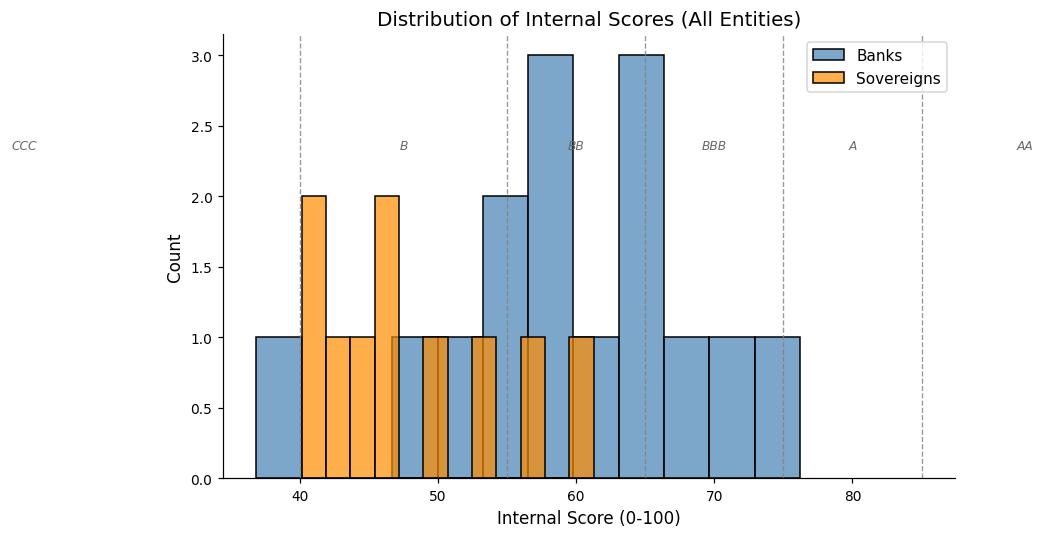

Chart (a) saved.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

bank_scores_series = banks_df["bank_internal_score"]
sov_scores_series  = sovereigns_df["sovereign_internal_score"]

sns.histplot(
    bank_scores_series, bins=12, color="steelblue", alpha=0.7,
    label="Banks", ax=ax, kde=False
)
sns.histplot(
    sov_scores_series, bins=12, color="darkorange", alpha=0.7,
    label="Sovereigns", ax=ax, kde=False
)

# Rating zone vertical lines and labels
boundaries = [
    (40, "B/CCC"), (55, "BB/B"), (65, "BBB/BB"), (75, "A/BBB"), (85, "AA/A")
]
zone_labels = [
    (0, 40, "CCC"), (40, 55, "B"), (55, 65, "BB"),
    (65, 75, "BBB"), (75, 85, "A"), (85, 100, "AA")
]

for threshold, label in boundaries:
    ax.axvline(threshold, color="grey", linestyle="--", linewidth=0.9, alpha=0.8)

y_text = ax.get_ylim()[1] * 0.85 if ax.get_ylim()[1] > 0 else 2.0
for lo, hi, zone_label in zone_labels:
    midpoint = (lo + hi) / 2
    ax.text(
        midpoint, y_text * 0.9, zone_label,
        ha="center", va="top", fontsize=8, color="dimgray",
        fontstyle="italic"
    )

ax.set_title("Distribution of Internal Scores (All Entities)")
ax.set_xlabel("Internal Score (0-100)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart_score_distribution.png", dpi=110, bbox_inches="tight")
plt.show()
print("Chart (a) saved.")

### (b) Top 10 Highest-Risk Entities by Internal Score

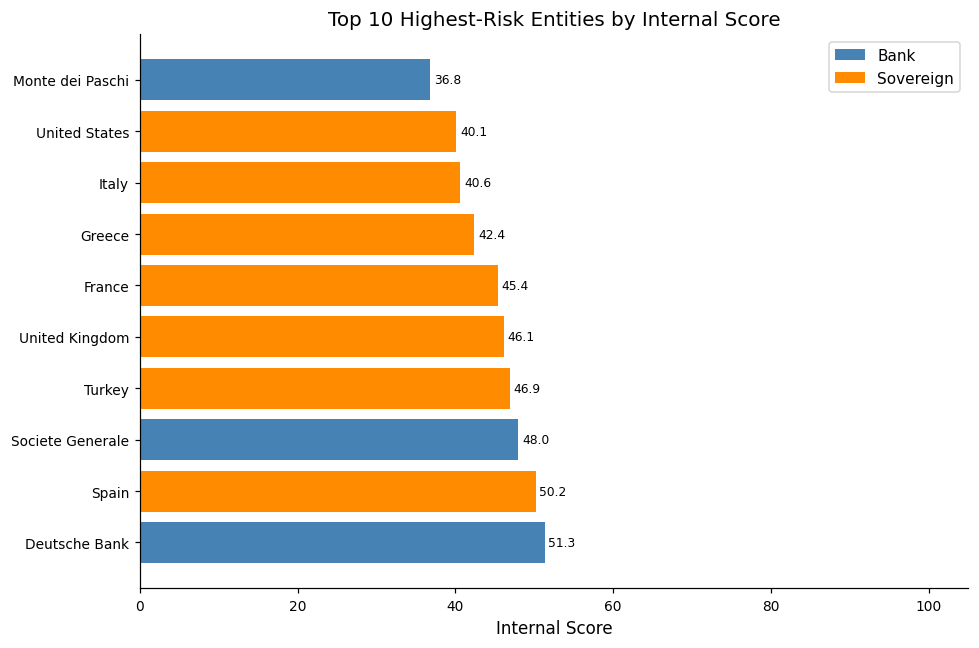

Chart (b) saved.


In [ ]:
# Combine all entities with their scores and types
all_scores = pd.concat([
    banks_df[["entity_name", "bank_internal_score"]].rename(
        columns={"bank_internal_score": "internal_score"}
    ).assign(entity_type="Bank"),
    sovereigns_df[["entity_name", "sovereign_internal_score"]].rename(
        columns={"sovereign_internal_score": "internal_score"}
    ).assign(entity_type="Sovereign")
], ignore_index=True)

top10_risk = all_scores.nsmallest(10, "internal_score").reset_index(drop=True)

color_map = {"Bank": "steelblue", "Sovereign": "darkorange"}
bar_colors = top10_risk["entity_type"].map(color_map)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(
    top10_risk["entity_name"],
    top10_risk["internal_score"],
    color=bar_colors
)

# Score labels on bars
for bar, score in zip(bars, top10_risk["internal_score"]):
    ax.text(
        bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
        f"{score:.1f}", va="center", ha="left", fontsize=8
    )

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="steelblue", label="Bank"),
    Patch(facecolor="darkorange", label="Sovereign")
]
ax.legend(handles=legend_elements)

ax.set_title("Top 10 Highest-Risk Entities by Internal Score")
ax.set_xlabel("Internal Score")
ax.set_xlim(0, 105)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart_top10_risk.png", dpi=110, bbox_inches="tight")
plt.show()
print("Chart (b) saved.")

### (c) CDS 5Y Spread Over 90 Days - Watchlist Entities

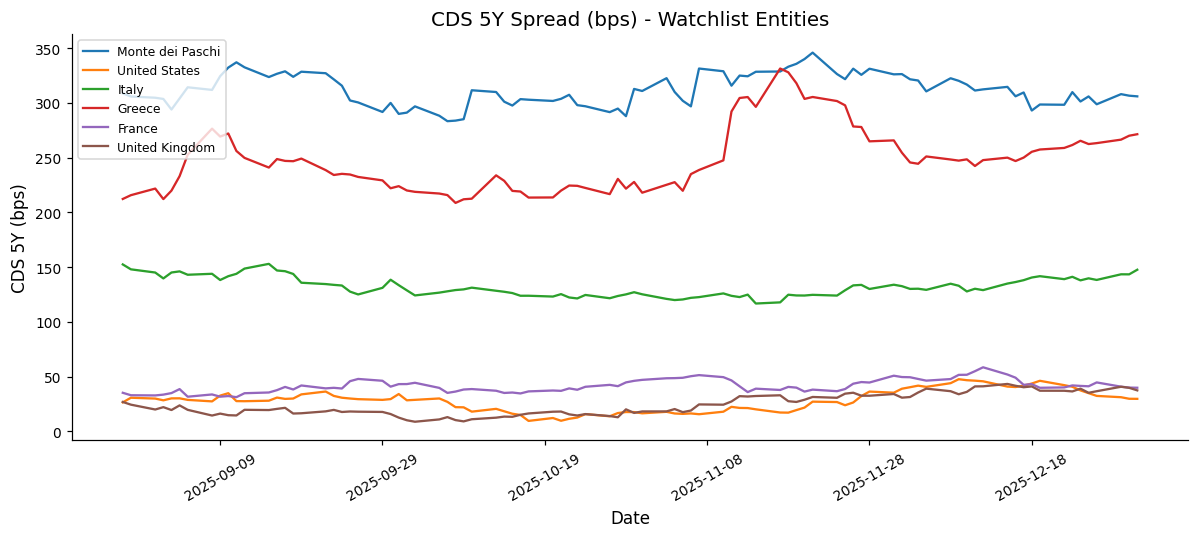

Chart (c) saved.


In [ ]:
# Select up to 6 watchlist entities for readability
watchlist_entities = watchlist_df["entity_name"].tolist()[:6]

fig, ax = plt.subplots(figsize=(11, 5))

for entity in watchlist_entities:
    entity_data = market_df[market_df["entity_name"] == entity].sort_values("date")
    ax.plot(entity_data["date"], entity_data["cds_5y_bps"], label=entity, linewidth=1.5)

ax.set_title("CDS 5Y Spread (bps) - Watchlist Entities")
ax.set_xlabel("Date")
ax.set_ylabel("CDS 5Y (bps)")
ax.legend(fontsize=8, loc="upper left")
ax.xaxis.set_major_locator(mticker.MaxNLocator(8))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart_cds_watchlist.png", dpi=110, bbox_inches="tight")
plt.show()
print("Chart (c) saved.")

### (d) Internal Score vs Market Alert Count

NameError: name 'rating_table' is not defined

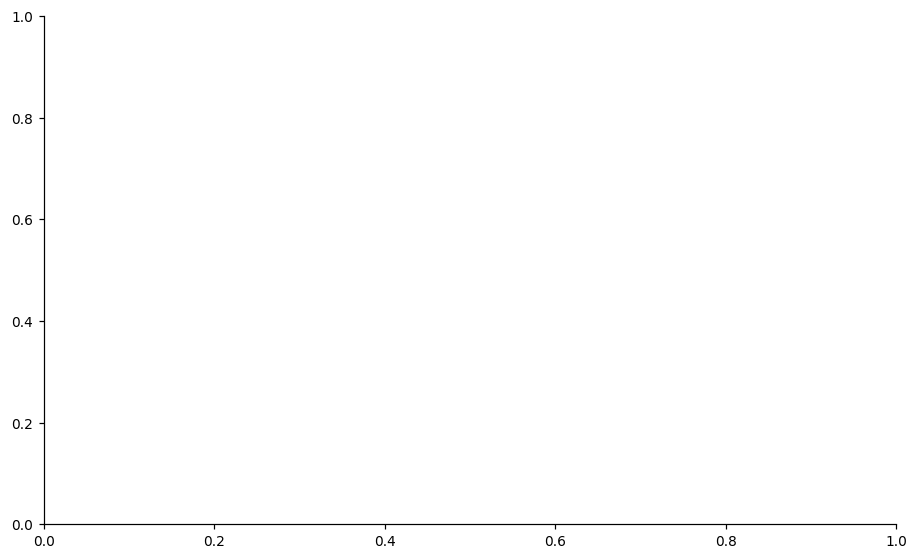

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

color_map2 = {"Bank": "steelblue", "Sovereign": "darkorange"}

for etype, group in rating_table.groupby("entity_type"):
    ax.scatter(
        group["internal_score"], group["market_alert_count"],
        c=color_map2[etype], label=etype, s=70, alpha=0.85, zorder=3
    )

# Annotate entity names
for _, row in rating_table.iterrows():
    ax.annotate(
        row["entity_name"],
        (row["internal_score"], row["market_alert_count"]),
        fontsize=6.5, ha="left", va="bottom",
        xytext=(2, 2), textcoords="offset points"
    )

# Reference lines
ax.axvline(60, color="red", linestyle="--", linewidth=1, alpha=0.7, label="Score threshold (60)")
ax.axhline(2,  color="purple", linestyle="--", linewidth=1, alpha=0.7, label="Alert threshold (2)")

ax.set_title("Internal Score vs Market Alert Count")
ax.set_xlabel("Internal Score")
ax.set_ylabel("Market Alert Count (Latest Date)")
ax.legend(fontsize=8)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart_score_vs_alerts.png", dpi=110, bbox_inches="tight")
plt.show()
print("Chart (d) saved.")

### (e) Market Variable Correlation Heatmap (Last 30 Trading Days)

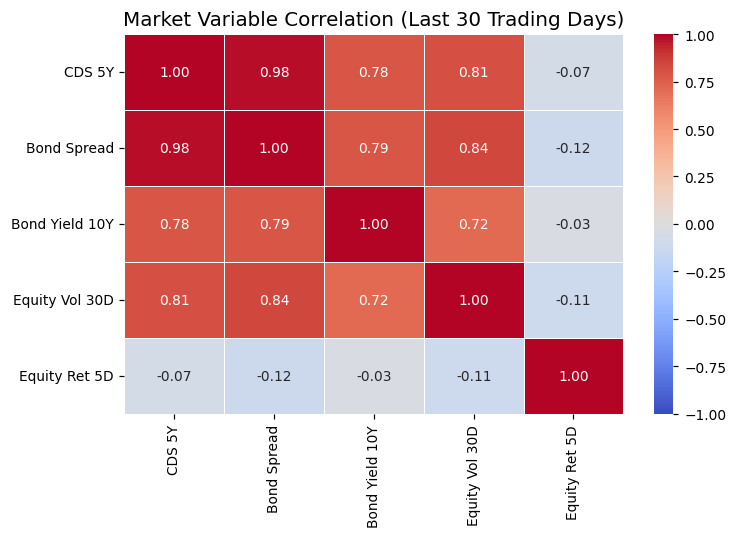

Chart (e) saved.


In [ ]:
# Select last 30 distinct trading days
last_30_dates = sorted(market_df["date"].unique())[-30:]
mkt_last30 = market_df[market_df["date"].isin(last_30_dates)]

corr_cols = [
    "cds_5y_bps", "bond_spread_bps", "bond_yield_10y",
    "equity_vol_30d", "equity_return_5d"
]

corr_matrix = mkt_last30[corr_cols].dropna().corr()

# Rename for display clarity
display_names = {
    "cds_5y_bps": "CDS 5Y",
    "bond_spread_bps": "Bond Spread",
    "bond_yield_10y": "Bond Yield 10Y",
    "equity_vol_30d": "Equity Vol 30D",
    "equity_return_5d": "Equity Ret 5D"
}
corr_matrix = corr_matrix.rename(index=display_names, columns=display_names)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
    vmin=-1, vmax=1, ax=ax, linewidths=0.5,
    annot_kws={"size": 9}
)
ax.set_title("Market Variable Correlation (Last 30 Trading Days)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart_correlation_heatmap.png", dpi=110, bbox_inches="tight")
plt.show()
print("Chart (e) saved.")

## 15. Key Conclusions

The following observations summarise the key findings from this credit risk monitoring exercise, covering portfolio quality, entity-level vulnerabilities, risk driver patterns, market signal dynamics, recommended actions, and model limitations.

---

**1. Overall Portfolio Quality**
The monitored portfolio exhibits a broadly investment-grade credit profile, with the majority of entities scoring in the BBB to A range on the internal model. Banks in core eurozone and Scandinavian markets (Nordea, ING Group, JPMorgan Chase, UBS) demonstrate solid composite scores driven by strong capital ratios and low NPL levels. Sovereign entities in Germany, Japan, and the United States anchor the high-quality end of the portfolio despite fiscal pressures.

**2. Most Vulnerable Entities**
Monte dei Paschi di Siena and Turkey represent the highest-risk positions in the portfolio. Monte dei Paschi is constrained by elevated NPL ratios, weak profitability, and the highest CDS spreads among banks. Turkey exhibits extreme inflation, a persistent current account deficit, and high political risk, producing a sub-investment-grade internal score reinforced by stressed market indicators. Greece and Brazil also warrant heightened attention given elevated debt burdens and volatile market signals.

**3. Key Risk Drivers Across the Portfolio**
For banks, the most frequently triggered risk drivers are cost efficiency (cost-to-income ratio) and asset quality (NPL ratio), particularly among Southern European institutions. For sovereigns, fiscal balance and debt sustainability are the most common constraints, reflecting the structural legacy of post-2008 fiscal expansion in France, Italy, Greece, and Brazil. Inflation is the dominant driver of Turkey's low sovereign score.

**4. Market Signal Patterns**
CDS spread and bond spread alerts are most concentrated among high-yield-adjacent entities, consistent with the risk hierarchy implied by internal scores. Equity volatility alerts cluster around Monte dei Paschi and Turkey, where the base volatility assumptions are highest. The correlation analysis of the last 30 trading days confirms that CDS spreads and bond spreads move in near-lockstep, while equity returns exhibit a negative relationship with both spread measures, as expected under risk-off conditions.

**5. Recommended Priority Actions**
The credit desk should immediately escalate Monte dei Paschi and Turkey for credit committee review, given sub-60 internal scores and concurrent market alerts. A formal credit review is recommended for Greece, Brazil, and Commerzbank. All remaining watchlist entities should be placed under enhanced monthly monitoring with updated scoring at the next reporting cycle. The desk should also review sovereign exposure concentration in Southern Europe given the co-movement risk between Italy, Greece, and Spain.

**6. Limitations and Model Caveats**
The internal scoring model is based on a static cross-sectional dataset as of 31 December 2025 and does not incorporate forward-looking analyst adjustments, sector overlays, or macroprudential policy factors. The weighting scheme reflects a generic multi-factor approach and should be recalibrated periodically against observed default data or rating transitions. Market data is synthetically generated and does not represent actual traded levels; live implementation would require integration with Bloomberg, Reuters, or equivalent data vendors. Additionally, the current account and FX reserve metrics for sovereign scoring carry lower granularity than sovereign-specific models used by rating agencies.
